In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns

In [12]:
from scipy.stats import bootstrap

In [2]:
plt.style.use("~/nice.mplstyle")

In [3]:
metric = "mae"
subregion = ".northern_hemisphere"

error = {}
#error["Nested-EAGLE 0.25\u00B0/06km"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/mse24h/experiments/data-years/all/inference-validation/obs-metrics/{metric}.convobs.nested-global{subregion}.nc", decode_timedelta=True)
error["Nested-EAGLE 0.25\u00B0/06km"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/mse06h/experiments/1.0deg-24km-latent/1x16encoders/inference-validation/obs-metrics/{metric}.convobs.nested-global{subregion}.nc", decode_timedelta=True)
error["GFS 54h"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-gfs-analysis/obs-metrics/{metric}.convobs.global{subregion}.nc", decode_timedelta=True)
error["GFS 30h"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-gfs-analysis/obs-metrics-30h/{metric}.convobs.global{subregion}.nc", decode_timedelta=True)
error["GFS 18h"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-gfs-analysis/obs-metrics-18h/{metric}.convobs.global{subregion}.nc", decode_timedelta=True)
error["GFS 06h"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-gfs-analysis/obs-metrics-06h/{metric}.convobs.global{subregion}.nc", decode_timedelta=True)

In [4]:
nice_names = lambda name : name.replace("_", " ").capitalize()

In [5]:
def single_plot(ax, dsdict, varname, sel=None, **kwargs):
    estimator = kwargs.pop("estimator", "median") 
    for label, xds in error.items():
        plotme = xds[varname] if sel is None else xds[varname].sel(**sel)
        df = plotme.to_dataframe().reset_index()
        sns.lineplot(
            data=df,
            x="fhr",
            y=varname,
            ax=ax,
            label=label,
            estimator=estimator,
            **kwargs,
        )
    xticks = plotme.fhr.values
    xticks = xticks if len(xticks)<10 else np.concatenate([ [xticks[0]], xticks[4::4]])
    ax.set(
        ylabel=metric.upper() if ax.get_subplotspec().is_first_col() else "",
        xlabel="Forecast Hour" if ax.get_subplotspec().is_last_row() else "",
        title=nice_names(varname) if ax.get_subplotspec().is_first_row() else "",
        xticks=xticks,
    )
    ax.legend(frameon=False)

In [6]:
def plot_surface_error(surface_vars, **kwargs):
    ncols = len(surface_vars)
    fig, axs = plt.subplots(1, ncols, figsize=(5*ncols, 4), constrained_layout=True)
    
    for varname, ax in zip(surface_vars, axs):
        single_plot(ax=ax, dsdict=error, varname=varname, **kwargs)
    return fig, axs

In [7]:
def plot_level_vars(level_vars, **kwargs):
    
    levels = next(iter(error.values())).level.values
    ncols = len(level_vars)
    nrows = len(levels)
    fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), constrained_layout=True)

    if ncols == 1:
        axs = [axs]
    if nrows == 1:
        axs = [axs]
    

    sel = kwargs.pop("sel", {})
    for level, axr in zip(levels, axs):
        for varname, ax in zip(level_vars, axr):
            
            sel["level"] = level
            single_plot(ax=ax, dsdict=error, varname=varname, sel=sel, **kwargs)
            ax.legend(title=f"{level} hPa", frameon=False)
    return fig, axs

In [8]:
surface_fields = ["surface_pressure", "10m_zonal_wind", "10m_meridional_wind", "2m_temperature", "2m_specific_humidity"]

In [9]:
pressure_fields = ["geopotential_height", "zonal_wind", "meridional_wind", "temperature", "specific_humidity"]

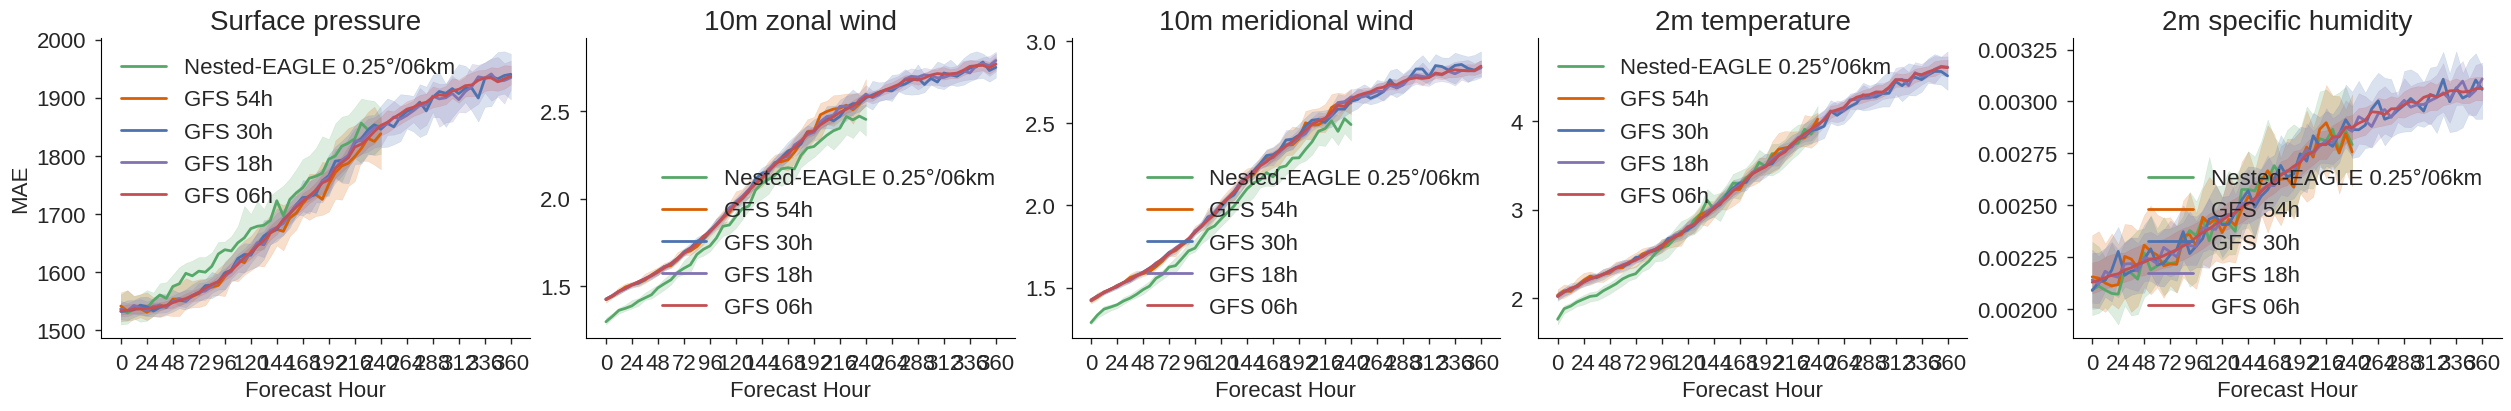

In [10]:
fig, axs = plot_surface_error(surface_fields)
#fig.savefig(f"figures/surface_10d_rmse_5fields.jpeg", dpi=300, bbox_inches="tight")

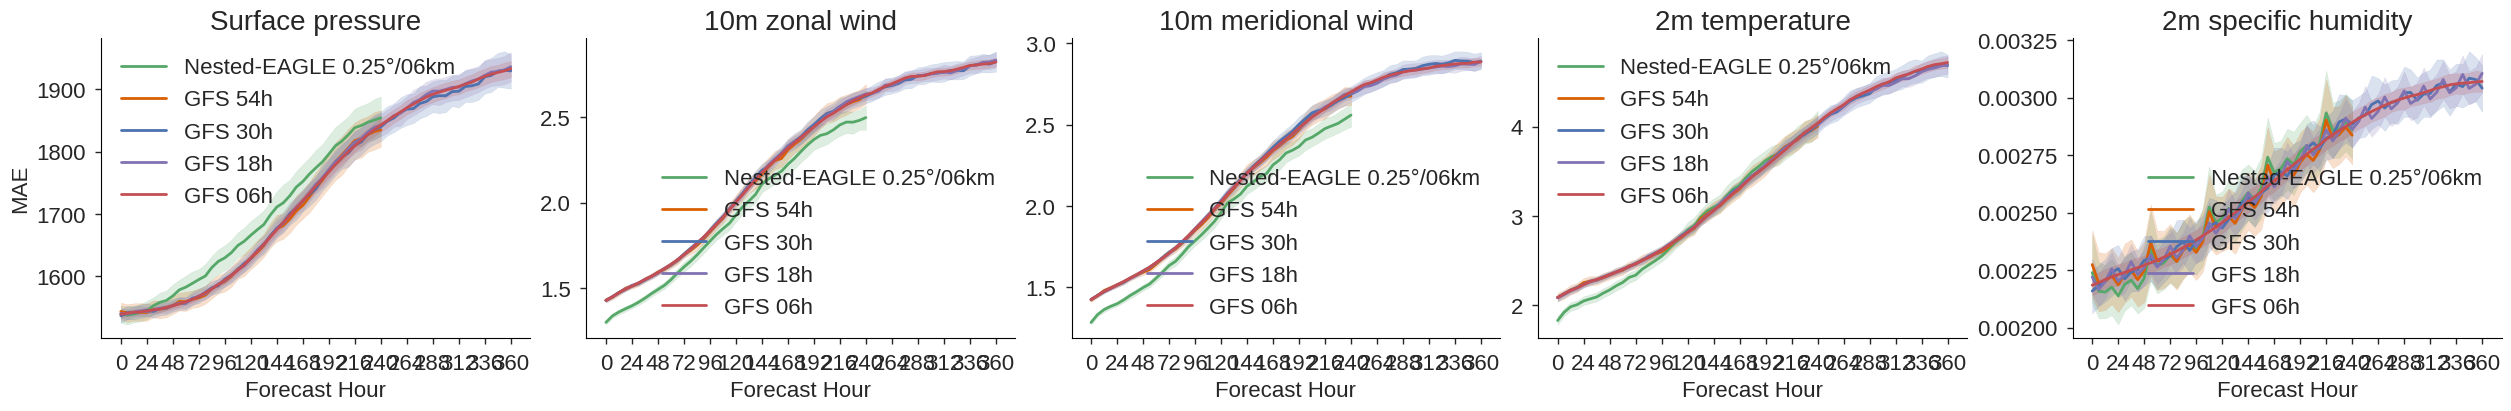

In [11]:
fig, axs = plot_surface_error(surface_fields, estimator="mean")

fig, axs = plot_level_vars(pressure_fields, estimator="mean")
#fig.savefig(f"figures/plevel_10d_rmse_6fields.jpeg", dpi=300, bbox_inches="tight")

GFS 54h 0.1139003075389553
GFS 30h 0.09153298104064955
GFS 18h 0.06670204715725703
GFS 06h 0.039579275618305765


<Axes: ylabel='Density'>

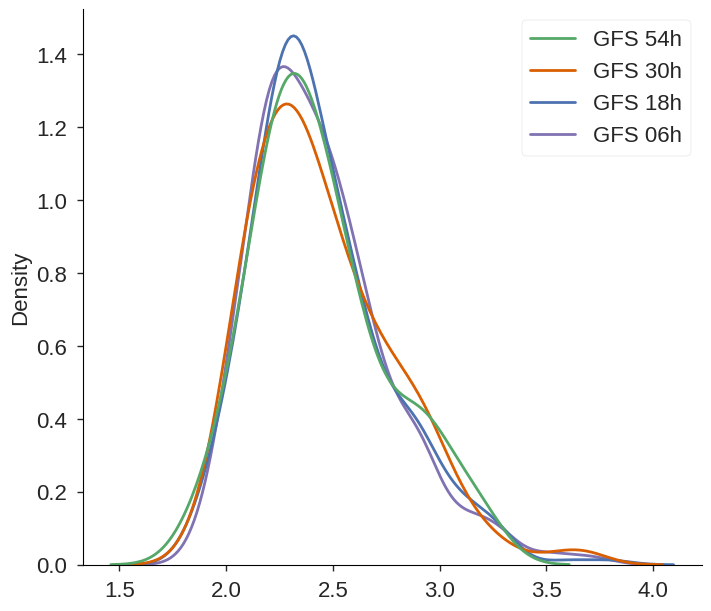

In [56]:
dflist = []
varname = "10m_zonal_wind"

for key in list(error.keys())[-4:]:
    xda = error[key][varname].sel(fhr=8*24, drop=True)
    xda.name = key
    res = bootstrap((xda.dropna("t0").values,), np.mean, confidence_level=0.95, method='percentile')
        
    ci_lower = res.confidence_interval.low
    ci_upper = res.confidence_interval.high
    ci_width = ci_upper - ci_lower
    print(f"{key} {ci_width}")
    dflist.append(xda)
#plt.figure()
#sns.violinplot(dflist)
#plt.figure()
#sns.pointplot(dflist)
plt.figure()
#sns.histplot(dflist, stat="density", kde=True, common_norm=False)
sns.kdeplot(dflist, common_norm=False)
        

In [24]:
dflist[0].values

array([0.00241571, 0.00187197, 0.00273746, 0.00234184, 0.00334241,
       0.00246831, 0.00284452, 0.00197093, 0.00252563, 0.00207585,
       0.00273681, 0.00228795, 0.00292673, 0.0022537 , 0.00313474,
       0.00176844, 0.00340871, 0.00212186, 0.00250957, 0.00215554,
       0.00343653, 0.00244926, 0.00241057,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
       0.00222151,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan, 0.00318066,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan, 0.00298417, 0.00432864,
       0.0030758 , 0.00435932, 0.00367104, 0.00425191, 0.00331423,
       0.00479143, 0.00326445, 0.0042333 , 0.00402987, 0.00450

In [34]:
ci_width

0.00025989316478366

In [58]:
t06 = error["GFS 06h"].t0
t18 = error["GFS 18h"].t0
t30 = error["GFS 30h"].t0
t54 = error["GFS 54h"].t0

In [59]:
len(t06), len(t18), len(t30), len(t54)

(1414, 472, 283, 158)

(array([39.,  0.,  0., 40.,  0.,  0., 40.,  0.,  0., 39.]),
 array([ 0. ,  1.8,  3.6,  5.4,  7.2,  9. , 10.8, 12.6, 14.4, 16.2, 18. ]),
 <BarContainer object of 10 artists>)

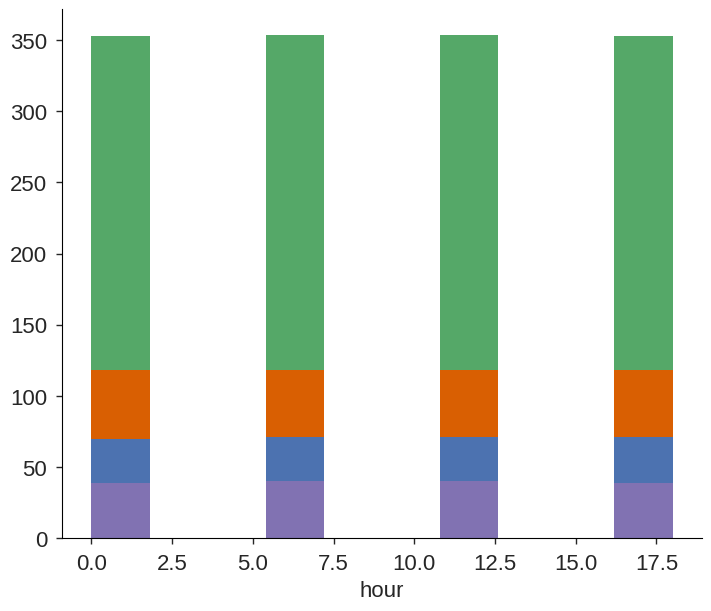

In [15]:
t06.dt.hour.plot.hist()
t18.dt.hour.plot.hist()
t30.dt.hour.plot.hist()
t54.dt.hour.plot.hist()